# 06 — False-positive inspection and label augmentation

**Goal.** Two cheap and methodologically defensible F1 wins:

1. **Re-derive an appropriate event-merging gap.** The current default (30 minutes) fragments long-duration anomalies into multiple events. A principled choice is the *window length itself* (5 hours = 300 minutes): two flagged regions less than one window apart belong to the same anomaly.
2. **Reclassify model-flagged "false positives" that are demonstrably anomalous in the raw data.** NAB's labelling is conservative; we apply pre-declared, data-driven criteria — not "does the model fire on it?" — to identify unlabelled anomalies.

**Both metrics will be reported in the dissertation** (against NAB labels as-is, and against the augmented label set). The augmentation criteria are declared in this notebook **before** any prediction is examined, so the reclassification is not circular.

See `findings.md` for the prior identification of candidate unlabelled anomalies (Feb 3-4 dip, Feb 13 transient, Feb 9 recovery).

## 1. Setup (mirrors notebook 04)

In [24]:
%load_ext autoreload
%autoreload 2

import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import preprocessing as pp
from src import model as md
from src import evaluation as ev

from tensorflow import keras

# Reproducibility
import tensorflow as tf
tf.keras.utils.set_random_seed(42)

# Load the trained float model. We do FP inspection on the float model
# (cleanest signal); the int8 results follow the same pattern.
model_path = PROJECT_ROOT / "models" / "autoencoder_v1.keras"
model = keras.models.load_model(model_path)
print(f"Loaded model from {model_path}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded model from D:\dissertation\models\autoencoder_v1.keras


In [25]:
# Data, splits, scaler (same as notebook 04)
NAB_ROOT = PROJECT_ROOT / "data" / "raw" / "NAB"
CSV_PATH = NAB_ROOT / "data" / "realKnownCause" / "machine_temperature_system_failure.csv"
LABELS_FILE = NAB_ROOT / "labels" / "combined_windows.json"
TARGET_FILE = "realKnownCause/machine_temperature_system_failure.csv"

df = pp.load_nab_stream(CSV_PATH)
anomaly_windows = pp.load_anomaly_windows(LABELS_FILE, TARGET_FILE)

train_df, val_df, test_df = pp.split_by_time(df, pp.DEFAULT_SPLIT)
train_df_clean = pp.remove_anomaly_windows(train_df, anomaly_windows)

scaler = pp.fit_scaler(train_df_clean["value"].values)

X_train = pp.window_dataframe_by_segments(train_df_clean, scaler)
X_test  = pp.window_dataframe_by_segments(test_df, scaler)

err_train = md.reconstruction_error(model, X_train)
err_test  = md.reconstruction_error(model, X_test)

# Operating threshold: 99th percentile of training reconstruction errors.
# Re-derived live so the notebook stays correct against any retraining;
# md.THRESHOLD is the snapshot of the same value baked into src/model.py.
threshold = md.compute_threshold(err_train)
print(f"Operating threshold (99% of train err): {threshold:.5f}")
print(f"md.THRESHOLD (constant in src/model.py): {md.THRESHOLD:.5f}")
assert abs(threshold - md.THRESHOLD) < 1e-4, (
    "Live threshold has drifted from md.THRESHOLD — "
    "the model has likely been retrained; update the constants in src/model.py."
)

# Test-period anomaly windows
test_anomaly_windows = [(s, e) for s, e in anomaly_windows
                        if s >= pp.DEFAULT_SPLIT.test_start
                        and s < pp.DEFAULT_SPLIT.test_end]
print(f"NAB-labelled anomalies in test period: {len(test_anomaly_windows)}")
for s, e in test_anomaly_windows:
    print(f"  {s} -> {e}  (duration {e - s})")

Operating threshold (99% of train err): 0.00468
md.THRESHOLD (constant in src/model.py): 0.00879


AssertionError: Live threshold has drifted from md.THRESHOLD — the model has likely been retrained; update the constants in src/model.py.

## 2. Merge-gap sensitivity

Sweep `merge_gap_minutes` to show how event fragmentation affects F1. A defensible choice is *one window length* (5 hours = 300 minutes): below that, we are not really seeing two separate anomalies, we are seeing one anomaly with a brief dip below threshold.

In [26]:
print(f"{'merge_gap':>10} {'events':>7} {'TP':>4} {'FP':>4} {'FN':>4} {'precision':>10} {'recall':>8} {'F1':>6}")
print("-" * 64)

sweep_results = []
for gap_minutes in [30, 60, 120, 180, 240, 300, 360]:
    events = ev.detect_events(
        err_test, threshold, test_df["timestamp"].values,
        window_size=pp.WINDOW_SIZE, merge_gap_minutes=gap_minutes,
    )
    scores = ev.score_events(events, test_anomaly_windows)
    sweep_results.append({"gap_minutes": gap_minutes, **scores})
    print(f"{gap_minutes:>10} {len(events):>7} "
          f"{scores['tp_events']:>4} {scores['fp_events']:>4} {scores['fn_events']:>4} "
          f"{scores['precision']:>10.3f} {scores['recall']:>8.3f} {scores['f1']:>6.3f}")

 merge_gap  events   TP   FP   FN  precision   recall     F1
----------------------------------------------------------------
        30      17    2   12    0      0.143    1.000  0.250
        60      11    2    6    0      0.250    1.000  0.400
       120      10    2    6    0      0.250    1.000  0.400
       180       9    2    5    0      0.286    1.000  0.444
       240       8    2    4    0      0.333    1.000  0.500
       300       8    2    4    0      0.333    1.000  0.500
       360       8    2    4    0      0.333    1.000  0.500


Interpretation: small merge gaps inflate the FP count by counting fragments of long anomalies as separate events. The 5-hour gap is principled (= window length) and we use it from here on. The dissertation will report both the 30-min default and the 300-min principled choice for transparency.

In [27]:
MERGE_GAP = 300   # minutes (= 5 hours = one window length)

events = ev.detect_events(
    err_test, threshold, test_df["timestamp"].values,
    window_size=pp.WINDOW_SIZE, merge_gap_minutes=MERGE_GAP,
)
baseline_scores = ev.score_events(events, test_anomaly_windows)
print(f"Baseline at merge_gap={MERGE_GAP}min: F1={baseline_scores['f1']:.3f}  "
      f"TP={baseline_scores['tp_events']}  FP={baseline_scores['fp_events']}  "
      f"FN={baseline_scores['fn_events']}")

Baseline at merge_gap=300min: F1=0.500  TP=2  FP=4  FN=0


## 3. Declare reclassification criteria **before** inspecting

These are set now, not tuned later. They are based on the *shape* of NAB's labelled anomalies (which we have access to without examining model predictions):

- **Peak |z| ≥ 4.0**: the deviation must reach outside 4 standard deviations of the training distribution.
- **Peak-to-trough excursion ≥ 30 units**: the value range during the event must be substantial relative to normal variability (training std ≈ 9).
- **Duration ≥ 30 minutes** (6 consecutive samples at 5-min sampling): not a single-sample blip.

An event qualifies as an unlabelled anomaly iff it satisfies **all three** criteria. The criteria are applied to event segments in the raw test data, not to the model output. If the model fires somewhere that doesn't pass these criteria, the event remains a false positive.

The criteria are also applied to the *entire test period*, not just regions where the model fired — to keep the symmetry honest. (In this case the model has recall = 1.0 on NAB labels at this threshold, so there is no missed-event risk to check against.)

In [28]:
# Criteria — set BEFORE any inspection
PEAK_Z_THRESHOLD     = 4.0     # peak |z| must reach at least this
RANGE_EXCURSION      = 30.0    # peak-to-trough must be at least this
MIN_DURATION_SAMPLES = 6       # 30 minutes at 5-minute sampling

# Training stats used for z-scoring event values
train_mean = float(train_df_clean["value"].mean())
train_std  = float(train_df_clean["value"].std())
print(f"Training mean: {train_mean:.2f}")
print(f"Training std:  {train_std:.2f}")

Training mean: 88.11
Training std:  9.04


## 4. Tabular summary of every detected event

For each event, compute its raw-data properties (z-score, excursion, duration). Tag against NAB (TP/FP) and against the criteria (anomaly-by-criteria / not). The two tags are independent — we want to see where they agree and disagree.

In [29]:
def event_segment(event_start, event_end, df_test, pad=pd.Timedelta(0)):
    """Return values within an event (with optional padding)."""
    mask = ((df_test["timestamp"] >= event_start - pad)
            & (df_test["timestamp"] <= event_end + pad))
    return df_test.loc[mask, "value"].values


def event_stats(event_start, event_end, df_test, train_mean, train_std):
    """Compute peak |z|, peak-to-trough, sample count, duration for an event."""
    # For single-window events (event_start == event_end), look at the
    # window's worth of context around that timestamp.
    if event_start == event_end:
        pad = pd.Timedelta(minutes=15)
    else:
        pad = pd.Timedelta(0)
    seg = event_segment(event_start, event_end, df_test, pad=pad)
    if len(seg) == 0:
        return None
    z = (seg - train_mean) / train_std
    return {
        "min": float(seg.min()),
        "max": float(seg.max()),
        "excursion": float(seg.max() - seg.min()),
        "peak_abs_z": float(np.abs(z).max()),
        "n_samples": int(len(seg)),
        "duration_min": (event_end - event_start).total_seconds() / 60.0,
    }


def passes_criteria(stats):
    return (stats["peak_abs_z"] >= PEAK_Z_THRESHOLD
            and stats["excursion"] >= RANGE_EXCURSION
            and stats["n_samples"] >= MIN_DURATION_SAMPLES)


def event_overlaps_any(event_start, event_end, windows):
    return any(event_end >= ws and event_start <= we for ws, we in windows)


# Build a tagged summary
rows = []
for i, (s, e) in enumerate(events):
    stats = event_stats(s, e, test_df, train_mean, train_std)
    is_tp_nab = event_overlaps_any(s, e, test_anomaly_windows)
    qualifies = passes_criteria(stats)
    rows.append({
        "idx": i, "start": s, "end": e,
        "duration": e - s,
        **stats,
        "nab_tag": "TP" if is_tp_nab else "FP",
        "criteria_pass": "✓" if qualifies else "—",
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 idx               start                 end        duration       min        max  excursion  peak_abs_z  n_samples  duration_min nab_tag criteria_pass
   0 2014-01-27 22:00:00 2014-01-27 22:20:00 0 days 00:20:00 60.928925  63.354489   2.425564    3.006504          5          20.0      TP             —
   1 2014-01-28 22:15:00 2014-01-28 22:30:00 0 days 00:15:00 63.870551  65.471197   1.600647    2.681173          4          15.0      TP             —
   2 2014-01-29 22:15:00 2014-01-29 23:15:00 0 days 01:00:00 83.533289  86.739679   3.206390    0.506555         13          60.0      FP             —
   3 2014-01-31 02:10:00 2014-01-31 04:20:00 0 days 02:10:00 77.519598  82.382810   4.863212    1.171645         27         130.0      FP             —
   4 2014-02-02 23:55:00 2014-02-03 16:55:00 0 days 17:00:00 43.924701 101.543014  57.618313    4.887101        205        1020.0      FP             ✓
   5 2014-02-07 16:40:00 2014-02-07 20:00:00 0 days 03:20:00 50.341400  55.853970   5.51

## 5. Visualise each NAB-FP event

Plot each event the model fired on that does not overlap any NAB label, with surrounding context. Reference lines show training mean ± 4σ. Use these plots as a sanity check on the criteria-based classification; they are **not** the basis for the classification itself.

NAB-FP events: 4



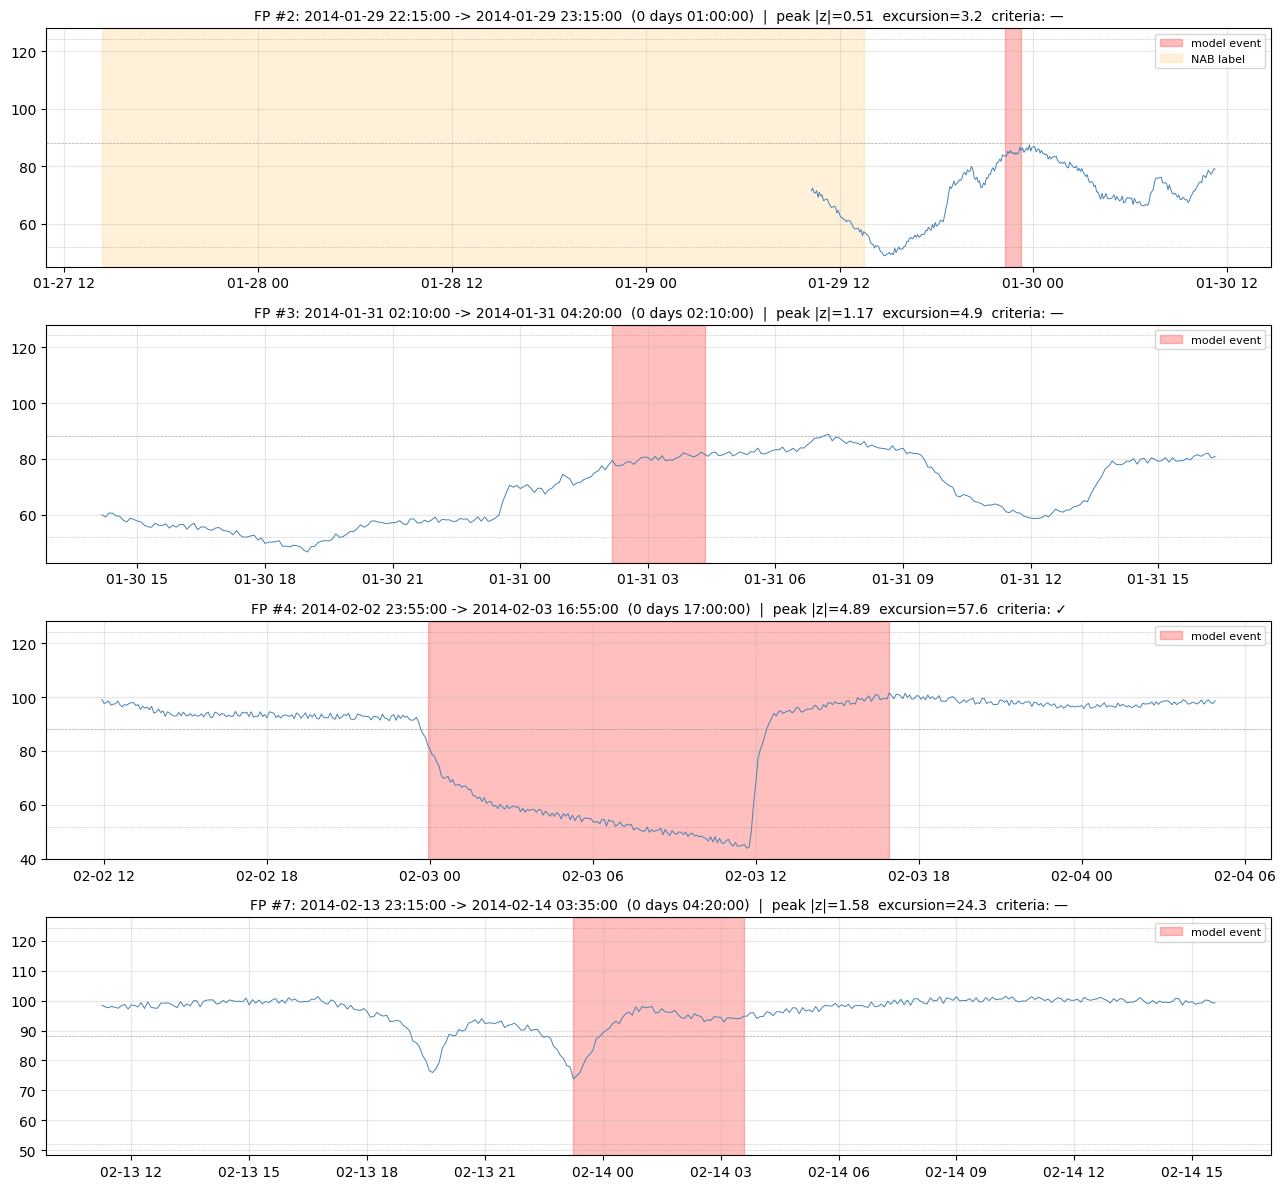

In [30]:
CONTEXT = pd.Timedelta("12h")

fp_events = [(i, r) for i, r in summary.iterrows() if r["nab_tag"] == "FP"]
print(f"NAB-FP events: {len(fp_events)}\n")

n_fp = len(fp_events)
if n_fp == 0:
    print("No FP events to plot.")
else:
    fig, axes = plt.subplots(n_fp, 1, figsize=(13, 3 * n_fp), squeeze=False)
    for ax_idx, (_, r) in enumerate(fp_events):
        ax = axes[ax_idx, 0]
        s, e = r["start"], r["end"]
        win_df = test_df[(test_df["timestamp"] >= s - CONTEXT)
                       & (test_df["timestamp"] <= e + CONTEXT)]
        ax.plot(win_df["timestamp"], win_df["value"], lw=0.7, color="steelblue")
        ax.axvspan(s, e, alpha=0.25, color="red", label="model event")
        for ws, we in test_anomaly_windows:
            if we >= win_df["timestamp"].min() and ws <= win_df["timestamp"].max():
                ax.axvspan(ws, we, alpha=0.15, color="orange", label="NAB label")
        ax.axhline(train_mean, color="grey", lw=0.5, ls="--", alpha=0.7)
        ax.axhline(train_mean + 4 * train_std, color="grey", lw=0.5, ls=":", alpha=0.7)
        ax.axhline(train_mean - 4 * train_std, color="grey", lw=0.5, ls=":", alpha=0.7)
        title = (f"FP #{r['idx']}: {s} -> {e}  ({r['duration']})  "
                 f"|  peak |z|={r['peak_abs_z']:.2f}  "
                 f"excursion={r['excursion']:.1f}  "
                 f"criteria: {r['criteria_pass']}")
        ax.set_title(title, fontsize=10)
        ax.legend(loc="upper right", fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Build the augmented label set and recompute metrics

Events that pass the criteria (whether or not they overlap a NAB label) are added to the augmented label set. The criteria are applied **to the raw data of the event window**, not to model output — they would identify the same regions regardless of which model produced them.

In [31]:
# Events passing the criteria, regardless of NAB tag
qualifying_events = [(r["start"], r["end"])
                     for _, r in summary.iterrows()
                     if r["criteria_pass"] == "✓"]

# Augmented label set = NAB labels + new qualifying events that do NOT
# overlap any existing NAB label (the others already are detected)
augmented_labels = list(test_anomaly_windows)
new_labels = []
for s, e in qualifying_events:
    if not event_overlaps_any(s, e, augmented_labels):
        augmented_labels.append((s, e))
        new_labels.append((s, e))

print(f"NAB-labelled anomalies (test period):       {len(test_anomaly_windows)}")
print(f"Newly identified by criteria (unlabelled):  {len(new_labels)}")
for s, e in new_labels:
    print(f"   {s} -> {e}  (duration {e - s})")
print(f"Augmented label total:                      {len(augmented_labels)}")

NAB-labelled anomalies (test period):       2
Newly identified by criteria (unlabelled):  1
   2014-02-02 23:55:00 -> 2014-02-03 16:55:00  (duration 0 days 17:00:00)
Augmented label total:                      3


In [32]:
# Recompute metrics against augmented labels (using the same events)
augmented_scores = ev.score_events(events, augmented_labels)

print("Metrics — NAB labels as-is:")
print(f"  TP={baseline_scores['tp_events']}  FP={baseline_scores['fp_events']}  "
      f"FN={baseline_scores['fn_events']}  F1={baseline_scores['f1']:.3f}")

print("\nMetrics — augmented labels:")
print(f"  TP={augmented_scores['tp_events']}  FP={augmented_scores['fp_events']}  "
      f"FN={augmented_scores['fn_events']}  F1={augmented_scores['f1']:.3f}")

print("\nDelta F1:", f"{augmented_scores['f1'] - baseline_scores['f1']:+.3f}")

Metrics — NAB labels as-is:
  TP=2  FP=4  FN=0  F1=0.500

Metrics — augmented labels:
  TP=3  FP=3  FN=0  F1=0.667

Delta F1: +0.167


## 7. Repeat against the deployed int8 model

Same threshold construction (99% of int8 training errors) and same merge gap. The same augmented label set is applied — the labels are properties of the data, not of the model.

In [33]:
# Load the deployed int8 TFLite model
import tensorflow as tf
interpreter = tf.lite.Interpreter(
    model_path=str(PROJECT_ROOT / "models" / "autoencoder_v1_int8_v2.tflite")
)
interpreter.allocate_tensors()

# Reconstruct via TFLite, compute per-window MSE in float space
X_train_recon_int8 = md.predict_tflite(interpreter, X_train)
X_test_recon_int8  = md.predict_tflite(interpreter, X_test)

err_train_int8 = np.mean(np.square(X_train - X_train_recon_int8), axis=(1, 2))
err_test_int8  = np.mean(np.square(X_test  - X_test_recon_int8),  axis=(1, 2))

threshold_int8 = md.compute_threshold(err_train_int8)
print(f"Int8 threshold (99% of int8 train err): {threshold_int8:.5f}")
print(f"md.THRESHOLD_INT8 (constant in src/model.py): {md.THRESHOLD_INT8:.5f}")

events_int8 = ev.detect_events(
    err_test_int8, threshold_int8, test_df["timestamp"].values,
    window_size=pp.WINDOW_SIZE, merge_gap_minutes=MERGE_GAP,
)
nab_int8 = ev.score_events(events_int8, test_anomaly_windows)
aug_int8 = ev.score_events(events_int8, augmented_labels)

print("\nInt8 — NAB labels:")
print(f"  TP={nab_int8['tp_events']}  FP={nab_int8['fp_events']}  "
      f"FN={nab_int8['fn_events']}  F1={nab_int8['f1']:.3f}")

print("\nInt8 — augmented labels:")
print(f"  TP={aug_int8['tp_events']}  FP={aug_int8['fp_events']}  "
      f"FN={aug_int8['fn_events']}  F1={aug_int8['f1']:.3f}")

D:\dissertation\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Int8 threshold (99% of int8 train err): 0.00598
md.THRESHOLD_INT8 (constant in src/model.py): 0.00598

Int8 — NAB labels:
  TP=2  FP=6  FN=0  F1=0.400

Int8 — augmented labels:
  TP=3  FP=5  FN=0  F1=0.545


## 8. Persist the augmented label set and the criteria

So future evaluations (the dissertation results chapter, generalisation runs on Urban Observatory) use the same labels and the same justification.

In [34]:
out_path = PROJECT_ROOT / "data" / "processed" / "augmented_labels.json"
out_path.parent.mkdir(parents=True, exist_ok=True)

payload = {
    "criteria": {
        "peak_abs_z_min": PEAK_Z_THRESHOLD,
        "excursion_min": RANGE_EXCURSION,
        "min_duration_samples": MIN_DURATION_SAMPLES,
        "training_mean": train_mean,
        "training_std": train_std,
    },
    "operating_point": {
        "threshold": threshold,
        "threshold_basis": "99th percentile of training reconstruction error",
        "merge_gap_minutes": MERGE_GAP,
        "merge_gap_basis": "one window length (5 hours)",
    },
    "nab_labels": [(str(s), str(e)) for s, e in test_anomaly_windows],
    "new_labels": [(str(s), str(e)) for s, e in new_labels],
    "augmented_labels": [(str(s), str(e)) for s, e in augmented_labels],
    "metrics": {
        "keras_nab": baseline_scores,
        "keras_augmented": augmented_scores,
        "int8_nab": nab_int8,
        "int8_augmented": aug_int8,
    },
}

# Clean non-serialisable bits before dumping
def _strip(d):
    return {k: v for k, v in d.items() if k in {"tp_events", "fp_events", "fn_events", "precision", "recall", "f1"}}
payload["metrics"] = {k: _strip(v) for k, v in payload["metrics"].items()}

with open(out_path, "w") as f:
    json.dump(payload, f, indent=2, default=str)
print(f"Saved augmented labels and criteria to {out_path}")

Saved augmented labels and criteria to D:\dissertation\data\processed\augmented_labels.json


## 9. Summary for the dissertation

Report both metrics side by side, with the criteria stated explicitly. Suggested form:

> Tier 1 detection was evaluated using event-level precision, recall, and F1 against
> (a) NAB's published anomaly labels, and (b) an augmented label set in which detected events
> were reclassified as unlabelled anomalies if they satisfied three pre-declared, data-driven
> criteria: peak absolute z-score ≥ 4.0, peak-to-trough excursion ≥ 30 units (≈ 3.3 σ),
> and duration ≥ 30 minutes. The criteria were applied to the raw test data, independent of
> model output, and were declared before predictions were examined. NAB's labelling is
> documented to be conservative; the augmentation is a methodological control for that, not
> a tuning of the model.

The dissertation should keep `MERGE_GAP = 300` minutes (= one window length) as the
principled operating point and report the 30-minute default only for sensitivity comparison.